# 🏠 House Price Prediction

## Overview

This project aims to predict houses sale prices in Ames, Iowa, using the [Ames Housing Dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques).

This analysis follows the methodics steps of machine learning workflow: exploratory data analysis, data cleaning, feature engineering, model training and evaluation.

**Target variable:** `SalePrice` — the sale price of each property in USD.

## Dataset

- **Source:** Kaggle — House Prices: Advanced Regression Techniques
- **Training set:** 1,460 properties · 79 features
- **Test set:** 1,459 properties

## Workflow

1. Imports & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Missing Values
4. Feature Engineering
5. Modelling & Evaluation
6. Conclusions

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150

---

## 1. Imports & Data Loading

In [27]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(f"Train set: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test set:  {test.shape[0]:,} rows × {test.shape[1]} columns")

train.head()

Train set: 1,460 rows × 81 columns
Test set:  1,459 rows × 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---

## 2. Exploratory Data Analysis (EDA)

Before any modelling, we need to understand the structure of the data, the distribution of the target variable, and the relationships between features and sale price.

In [28]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### 2.1 Target Variable Distribution

We begin by examining the distribution of `SalePrice`. Many regression models assume normally distributed residuals, so understanding the shape of the target is an important first step.

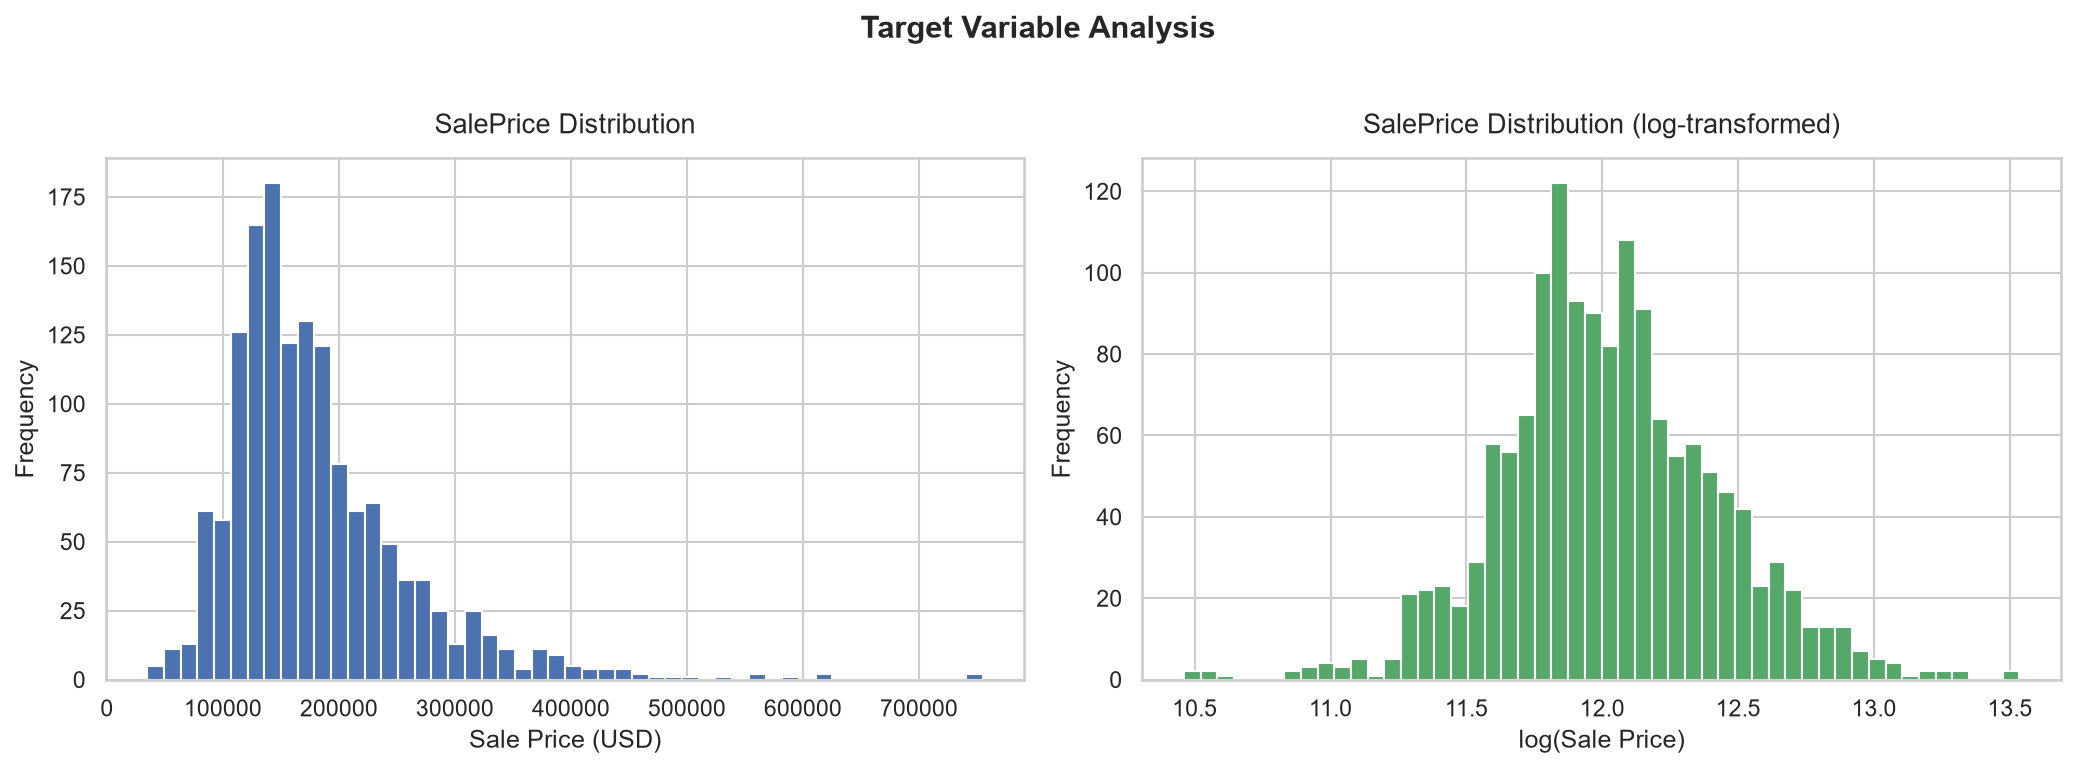

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train["SalePrice"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("SalePrice Distribution", fontsize=13, pad=12)
axes[0].set_xlabel("Sale Price (USD)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(train["SalePrice"]), bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("SalePrice Distribution (log-transformed)", fontsize=13, pad=12)
axes[1].set_xlabel("log(Sale Price)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Target Variable Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/target_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

We transform the original distribution by applying a logarithm to it, since as observed in the graph, it suffers from a severe right skew. We do this because a vast majority of the regression models tend to assume normally distributed residuals, and with the log transformations we generate a near-normal distribution from which the models will benefit. From now on, the target variable will be log1p(SalePrice)

### 2.2 Correlation with SalePrice

We identify the numerical features most correlated with the target variable.

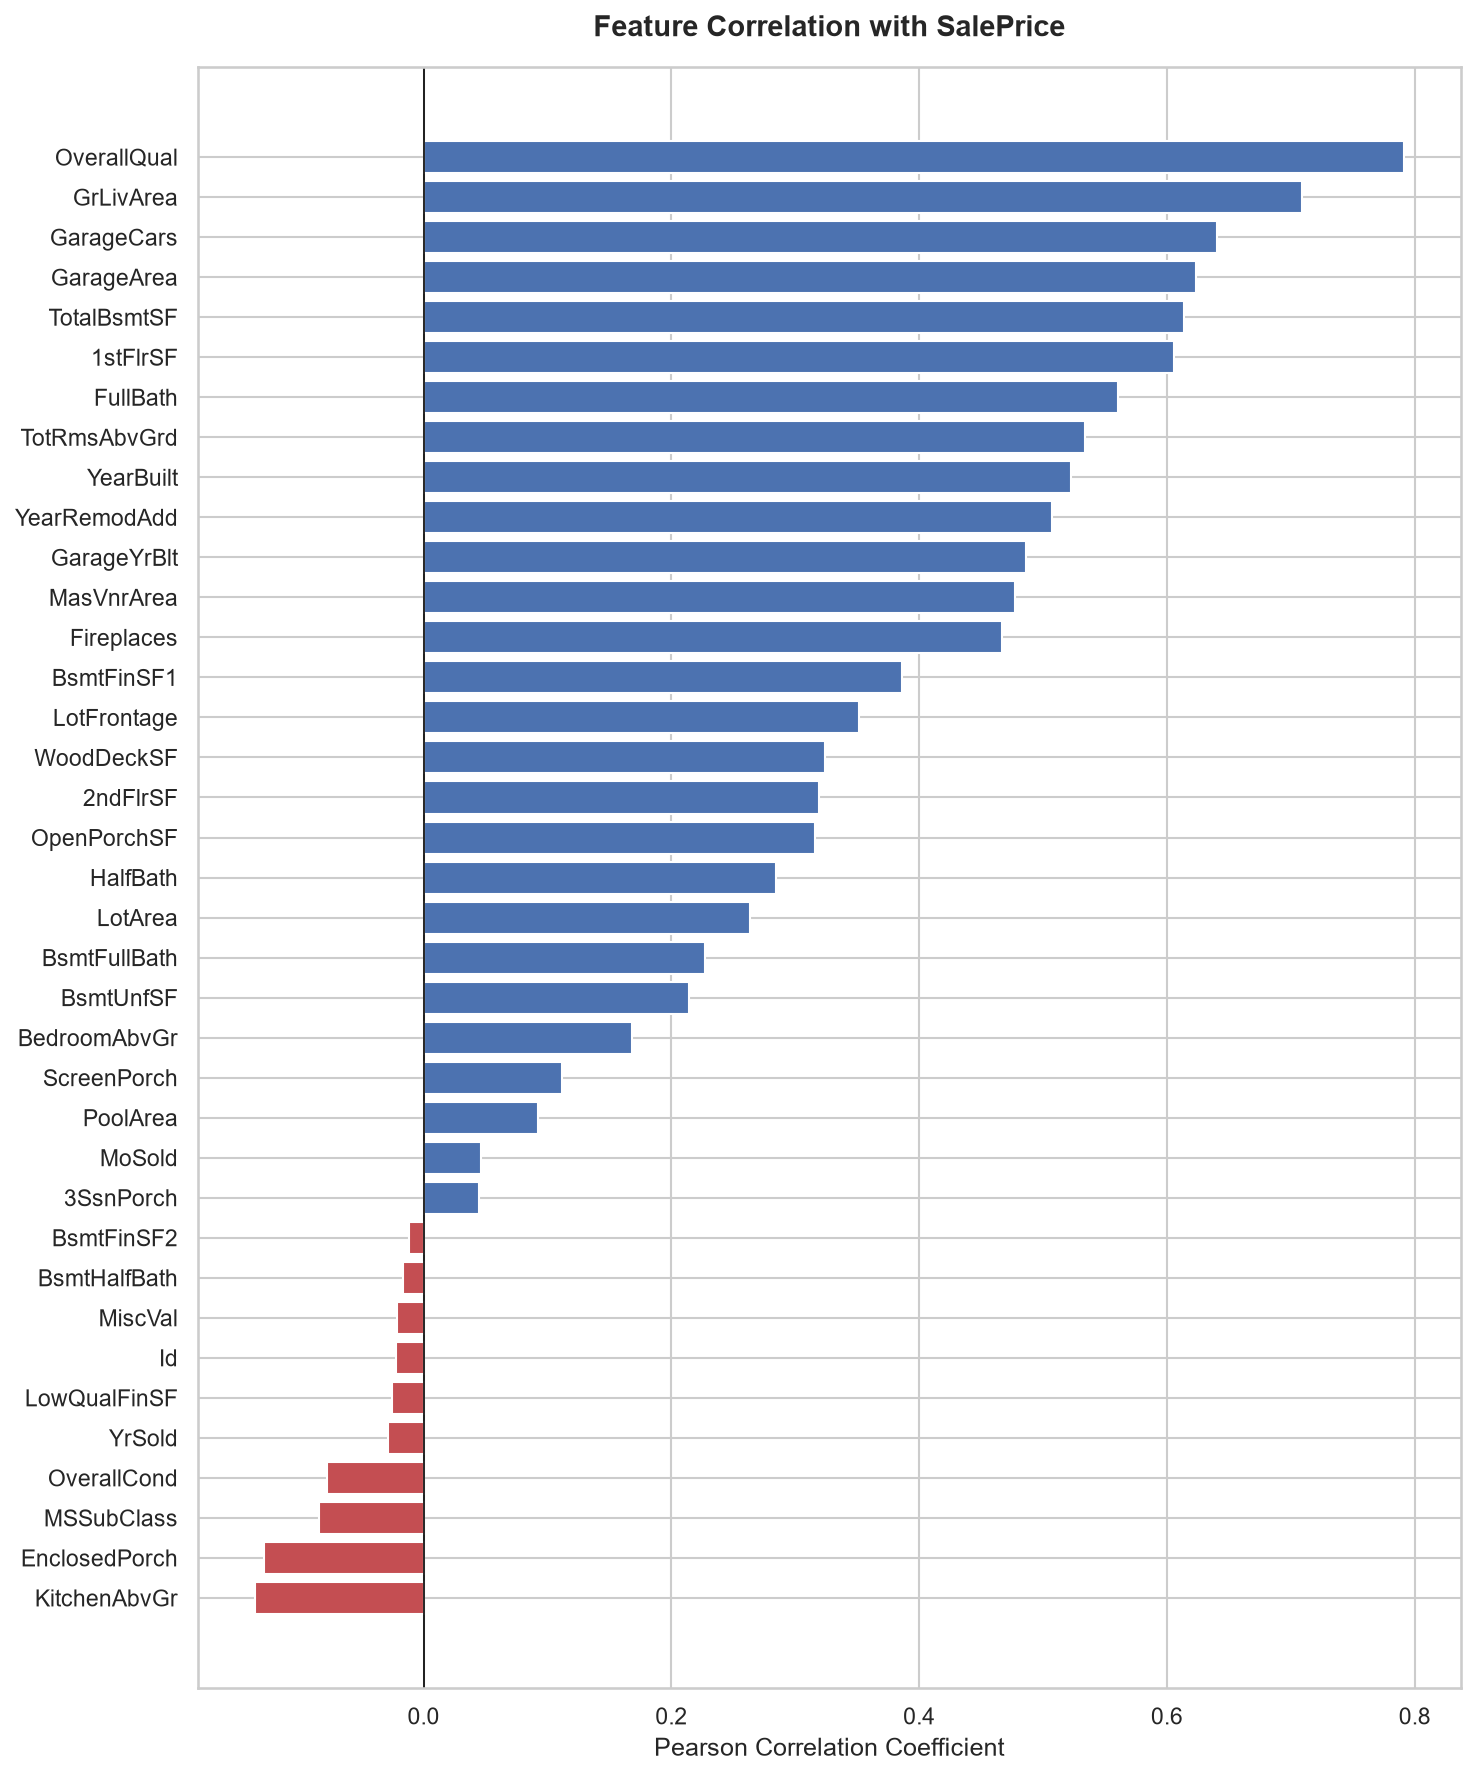

In [30]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
correlations = train[numeric_cols].corr()["SalePrice"].drop("SalePrice").sort_values()

fig, ax = plt.subplots(figsize=(10, 12))

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in correlations]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with SalePrice", fontsize=14, pad=15, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient")

plt.tight_layout()
plt.savefig("../images/correlations.png", bbox_inches="tight", dpi=300)
plt.show()

### 2.3 Top Features vs SalePrice

We visualise the relationship between `SalePrice` and the five most correlated numerical features.

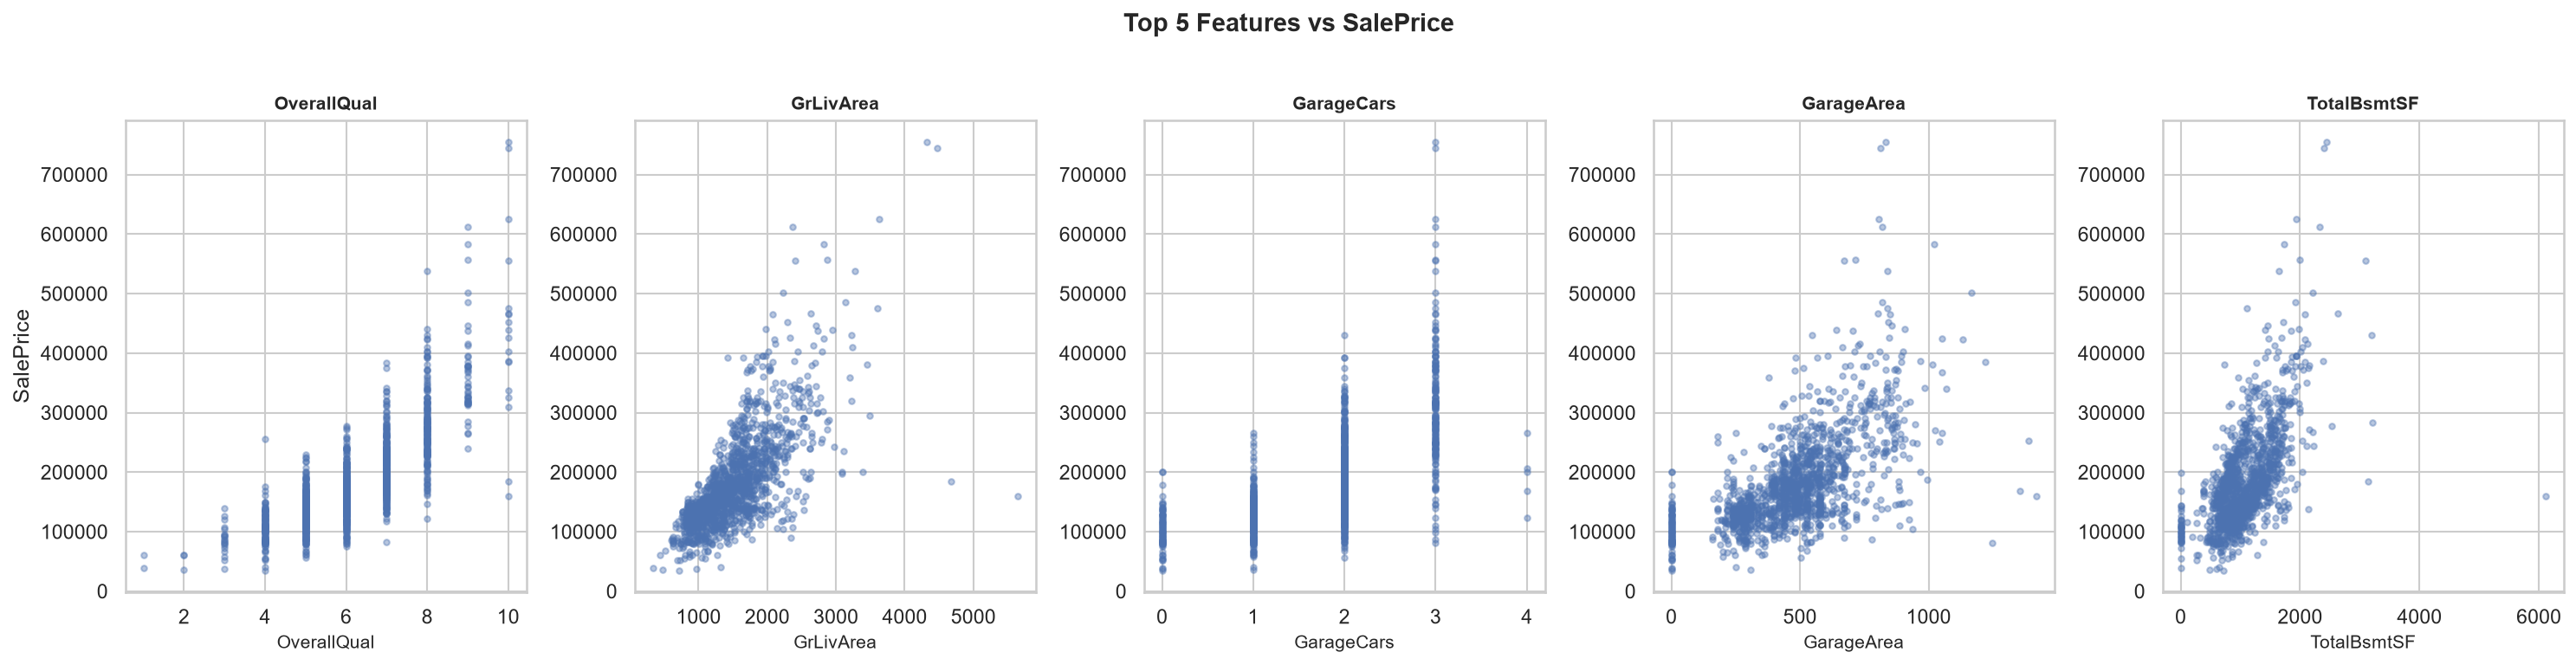

In [31]:
top_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, feature in zip(axes, top_features):
    ax.scatter(train[feature], train["SalePrice"], alpha=0.4, s=10, color="#4C72B0")
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel("SalePrice" if ax == axes[0] else "")
    ax.set_title(f"{feature}", fontsize=10, fontweight="bold")

plt.suptitle("Top 5 Features vs SalePrice", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/top_features.png", bbox_inches="tight", dpi=300)
plt.show()

---

## 3. Data Cleaning & Missing Values

In real world datasets are rarely clean and completed. Missing values are common, as well as uninformative features which provide little value to our model training. Besides, we must ensure that all data is in the correct format so our machine learning algorithm can process it.

### 3.1 Missing Value Analysis

In [32]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_pct
})

print(missing_df.to_string())

              Missing Values  Percentage (%)
PoolQC                  1453           99.52
MiscFeature             1406           96.30
Alley                   1369           93.77
Fence                   1179           80.75
MasVnrType               872           59.73
FireplaceQu              690           47.26
LotFrontage              259           17.74
GarageType                81            5.55
GarageYrBlt               81            5.55
GarageFinish              81            5.55
GarageQual                81            5.55
GarageCond                81            5.55
BsmtExposure              38            2.60
BsmtFinType2              38            2.60
BsmtQual                  37            2.53
BsmtCond                  37            2.53
BsmtFinType1              37            2.53
MasVnrArea                 8            0.55
Electrical                 1            0.07


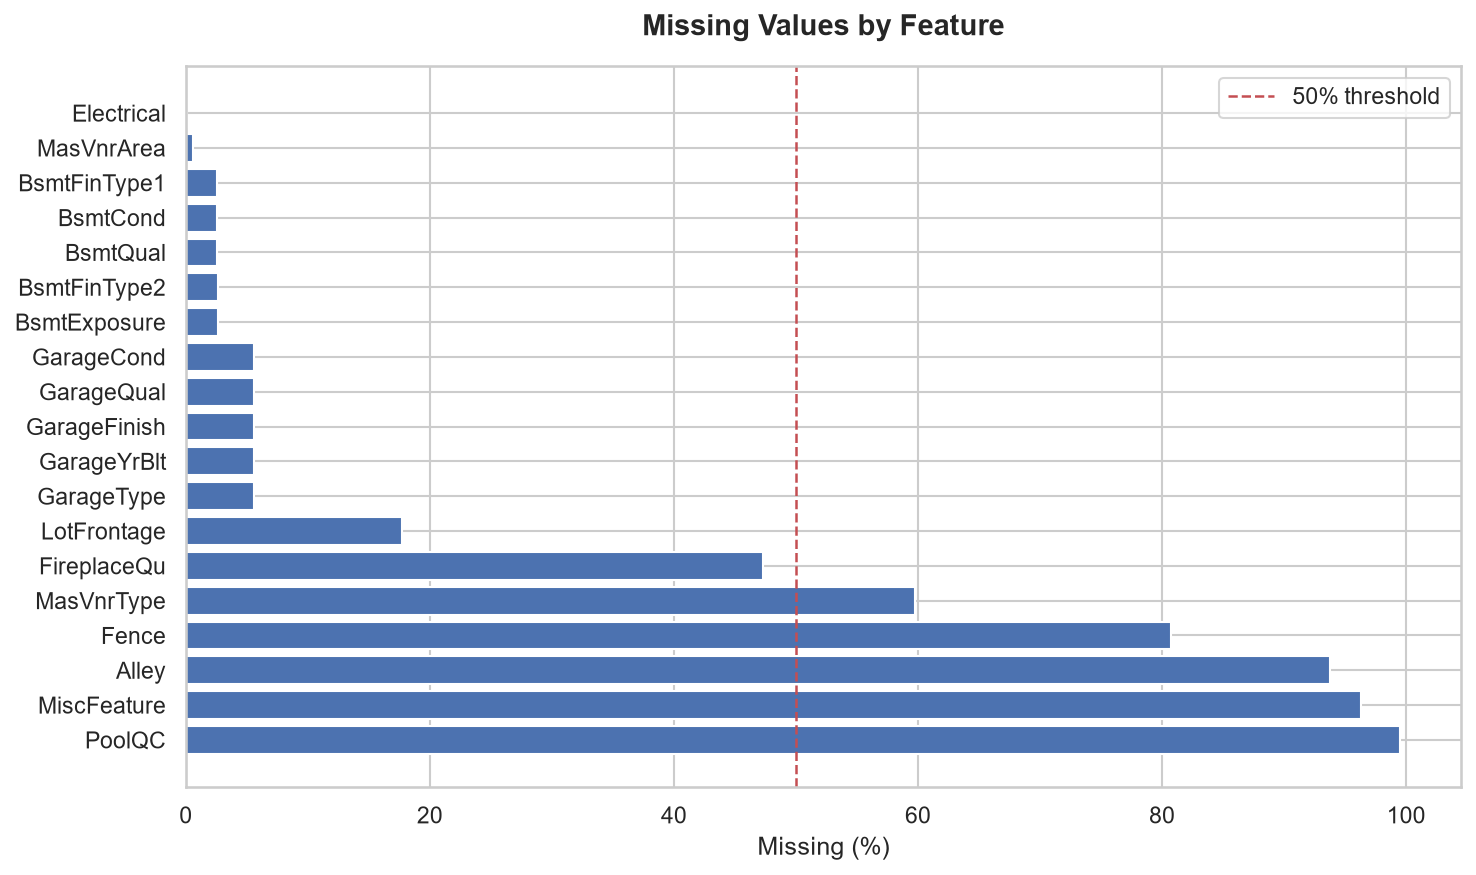

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(missing_df.index, missing_df["Percentage (%)"], color="#4C72B0", edgecolor="white")
ax.axvline(50, color="#C44E52", linestyle="--", linewidth=1.2, label="50% threshold")
ax.set_title("Missing Values by Feature", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Missing (%)")
ax.legend()

plt.tight_layout()
plt.savefig("../images/missing_values.png", bbox_inches="tight", dpi=300)
plt.show()

### 3.2 Handling Missing Values

We apply different strategies depending on the nature and volume of missing data:

- **Features with >50% missing values** are dropped — they carry too little information to be useful. Nonetheless, we need to be careful with categorical features like PoolQC, if its column is empty it means the property lacks that feature. 
- **Categorical features** with missing values are filled with `"None"`, as the absence of that feature means provides meaningful information(the lack of value in PoolQC is almost always because there's no pool in the property).
- **Numerical features** are filled with the median, which is more robust to outliers than the mean.

In [34]:
# Categorical: fill with "None" — absence is meaningful information
categorical_cols = train.select_dtypes(include="object").columns
for col in categorical_cols:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

# Numerical: fill with median
numerical_cols = train.select_dtypes(include=np.number).columns.drop("SalePrice")
for col in numerical_cols:
    median = train[col].median()
    train[col] = train[col].fillna(median)
    test[col] = test[col].fillna(median)

# Verify
remaining_missing = train.isnull().sum().sum()
print(f"Remaining missing values in train: {remaining_missing}")

Remaining missing values in train: 0


---

## 4. Feature Engineering

Machine learning models require numerical input. We convert categorical features into numbers and create new features that may improve predictive power.

### 4.1 Encoding Categorical Variables

Categorical features require different treatment depending on their nature:

- **Ordinal features** (quality and condition ratings) have a natural order. We map them manually to preserve that order — e.g. `Excellent > Good > Average > Fair > Poor`.
- **Nominal features** (neighbourhood, roof type, etc.) have no inherent order. We apply one-hot encoding to avoid imposing a false ordinal relationship.

This distinction prevents the model from learning misleading relationships from arbitrary numeric labels.

Next module, we label encode all the ordinal columns regarding quality features, which present an intrinsic order. 

In [35]:
# Standard quality scale used across most Ames quality/condition features
quality_map = {
    "None": 0,
    "Po": 1,   # Poor
    "Fa": 2,   # Fair
    "TA": 3,   # Typical/Average
    "Gd": 4,   # Good
    "Ex": 5    # Excellent
}

# Features that follow the standard quality scale
quality_cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual", "FireplaceQu",
    "GarageQual", "GarageCond"
]

for col in quality_cols:
    if col in train.columns:
        train[col] = train[col].map(quality_map)
        test[col] = test[col].map(quality_map)

print("Ordinal quality features encoded.")
print(train[quality_cols].head())

Ordinal quality features encoded.
   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  
0            0           3           3  
1            3           3           3  
2            3           3           3  
3            4           3           3  
4            3           3           3  


This is for the rest of the ordinal features, which display their own scales

In [36]:
# These ordinal features use their own specific scales
ordinal_maps = {
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
}

for col, mapping in ordinal_maps.items():
    if col in train.columns:
        train[col] = train[col].map(mapping)
        test[col] = test[col].map(mapping)

print("Custom ordinal features encoded.")

Custom ordinal features encoded.


Final module encodes the rest of the labels, which corresponds to the nominal features that don't include any natural order

In [37]:
# Everything still categorical (object) is nominal → one-hot encode
train["is_train"] = 1
test["is_train"] = 0
test["SalePrice"] = 0  # placeholder to align columns

combined = pd.concat([train, test], axis=0)

nominal_cols = combined.select_dtypes(include="object").columns.tolist()
print(f"One-hot encoding {len(nominal_cols)} nominal features...")

combined = pd.get_dummies(combined, columns=nominal_cols, drop_first=True)

# Split back
train = combined[combined["is_train"] == 1].drop(columns=["is_train"])
test = combined[combined["is_train"] == 0].drop(columns=["is_train", "SalePrice"])

print(f"\nTrain shape after encoding: {train.shape}")
print(f"Test shape after encoding:  {test.shape}")
print(f"Remaining categorical columns: {len(train.select_dtypes(include='object').columns)}")

One-hot encoding 30 nominal features...

Train shape after encoding: (1460, 225)
Test shape after encoding:  (1459, 224)
Remaining categorical columns: 0
